# Training (wandb) — method comparison

Pulls the FORGE peg-insert **training** runs from wandb and compares the three methods on
their **final** logged metrics. Runs are selected by `ENTITY / PROJECT` (+ optional `TAG`);
each run's wandb **group** names its method, and every run in a group is one **agent**.

For `hur/sim_force` this is 3 groups x 5 agents = 15 runs.

**Per-run (per-agent) final metrics** — read straight from `run.summary`:
- **success rate** — `Episode / Success rate` (fraction -> %).
- **break rate** — `Break / rate (%)`.
- **average force** — `Force / magnitude (mean)` (N).
- **max force** — `Force / magnitude (max)` (N).

**Plots** (mirroring `real_robot_eval_analysis.ipynb`)
1. *Among agents* (n = agents/method): 2x2 bars (success, break, avg force, max force),
   95% CI across agents; a dot per agent's max force on the max-force panel.
2. Stacked per-agent **rates** — one stack per method, one segment per agent, for success
   rate (left) and break rate (right), each segment labeled with that agent's value.
3. *Learning curves* — success rate (left) and mean reward (right) vs env steps, mean with
   a 95% CI band across agents (this one uses each run's logged **history**, not the summary).

> Note: wandb stores only per-run *final aggregates* (rates + forces), so — unlike the
> real-robot notebook — there is no per-trajectory (n=100) plot and the stacked plot shows
> per-agent **rates**, not integer success/break counts out of 20.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import wandb
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Global variables

In [2]:
# ---- wandb selection: all runs matching ENTITY / PROJECT (+ TAG if set) ----
ENTITY  = "hur"          # wandb entity
PROJECT = "sim_force"    # wandb project
TAG     = None           # None/"" -> every run in the project; else keep runs carrying this tag

FIG_DIR = "wandb_training_figs"

# ---- wandb summary keys (from learning/sac.py) ----
KEY_SUCCESS   = "Episode / Success rate"       # fraction 0..1  -> scaled to %
KEY_BREAK     = "Break / rate (%)"             # already 0..100
KEY_FORCE_AVG = "Force / magnitude (mean)"     # N
KEY_FORCE_MAX = "Force / magnitude (max)"      # N
KEY_REWARD    = "Reward / Total reward (mean)" # mean episodic reward (learning curve)

# ---- method ordering / styling (unknown groups fall back to a palette) ----
METHOD_ORDER   = ["contact_baseline", "contact_hist8", "dyn_pinv"]
KNOWN_COLORS   = {"contact_baseline": "#4C72B0",
                  "contact_hist8":    "#DD8452",
                  "dyn_pinv":         "#55A868"}
KNOWN_LABELS   = {"contact_baseline": "Contact\nBaseline",
                  "contact_hist8":    "Contact\nHist-8",
                  "dyn_pinv":         "Dyn Pinv"}
AGENT_CMAP = plt.cm.viridis        # per-agent shading in the stacked plot

CI = 0.95                          # confidence level for the error bars

## Data loading — pull final metrics from wandb

Every run under `ENTITY/PROJECT` (optionally filtered to `TAG`) is fetched; its wandb
**group** is the method and its **agent index** is parsed from the run name (`..._agent<i>`,
else assigned in fetch order within the group). One row per run in `per_agent`.

In [3]:
api = wandb.Api(timeout=60)
filters = None if not TAG else {"tags": {"$in": [TAG]}}
runs = api.runs(f"{ENTITY}/{PROJECT}", filters=filters)

rows = []
for r in runs:
    if TAG and TAG not in (r.tags or []):        # belt-and-suspenders on the tag filter
        continue
    s = r.summary
    m = re.search(r"agent[_-]?(\d+)", r.name or "")
    rows.append(dict(
        run=r.name, method=r.group, state=r.state,
        agent=int(m.group(1)) if m else np.nan,
        success_rate=100.0 * s.get(KEY_SUCCESS, np.nan),   # fraction -> %
        break_rate=s.get(KEY_BREAK, np.nan),               # already %
        avg_force=s.get(KEY_FORCE_AVG, np.nan),
        max_force=s.get(KEY_FORCE_MAX, np.nan)))

per_agent = pd.DataFrame(rows)

# methods present, ordered by METHOD_ORDER then any extras alphabetically
present = list(per_agent["method"].dropna().unique())
METHODS = [m for m in METHOD_ORDER if m in present] + sorted(m for m in present if m not in METHOD_ORDER)
_pal = plt.cm.tab10(np.linspace(0, 1, 10))
METHOD_COLORS = {m: KNOWN_COLORS.get(m, tuple(_pal[i % 10])) for i, m in enumerate(METHODS)}
METHOD_LABELS = {m: KNOWN_LABELS.get(m, m.replace("_", "\n")) for m in METHODS}

# fill any missing agent index in fetch order within each method; sort for stable stacks
per_agent["agent"] = (per_agent.groupby("method")["agent"]
                               .transform(lambda a: a.where(a.notna(), other=pd.Series(range(len(a)), index=a.index))))
per_agent["agent"] = per_agent["agent"].astype(int)
per_agent["method"] = pd.Categorical(per_agent["method"], categories=METHODS, ordered=True)
per_agent = per_agent.sort_values(["method", "agent"]).reset_index(drop=True)

n_by_method = per_agent.groupby("method", observed=True).size()
print(f"loaded {len(per_agent)} runs across {len(METHODS)} methods "
      f"(TAG={TAG!r}); agents/method: {n_by_method.to_dict()}")
missing = per_agent[["success_rate","break_rate","avg_force","max_force"]].isna().any(axis=1)
if missing.any():
    print("WARNING: runs missing one or more metric keys:\n",
          per_agent.loc[missing, ["run","method"]].to_string(index=False))
per_agent

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hunter/.netrc.


loaded 15 runs across 3 methods (TAG=None); agents/method: {'contact_baseline': 5, 'contact_hist8': 5, 'dyn_pinv': 5}


,run,method,state,agent,success_rate,break_rate,avg_force,max_force
0,contact_baseline_agent0,contact_baseline,finished,0,94.676806,3.041825,1.862425,10.983860
1,contact_baseline_agent1,contact_baseline,finished,1,94.007491,3.370786,2.141552,11.268016
2,contact_baseline_agent2,contact_baseline,finished,2,91.176471,5.514706,1.655021,12.632860
3,contact_baseline_agent3,contact_baseline,finished,3,85.000000,1.538462,1.598411,11.226282
4,contact_baseline_agent4,contact_baseline,finished,4,90.038314,2.681992,1.932183,12.939536
5,contact_hist8_agent0,contact_hist8,finished,0,94.052045,5.947956,2.772999,11.721176
6,contact_hist8_agent1,contact_hist8,finished,1,89.298893,6.273063,2.639074,13.516724
7,contact_hist8_agent2,contact_hist8,finished,2,93.478261,6.521739,1.453746,14.269962
8,contact_hist8_agent3,contact_hist8,finished,3,89.312977,1.526718,1.690364,13.364081
9,contact_hist8_agent4,contact_hist8,finished,4,94.339623,3.773585,1.238363,11.728178


## Plot 1 — averaged **among agents** (sample = agents per method)

For each method the sample is its per-agent final values. Bars are the across-agent mean;
error bars are the 95% CI (t-interval). On the max-force panel a dot marks each agent's
own `Force / magnitude (max)`.

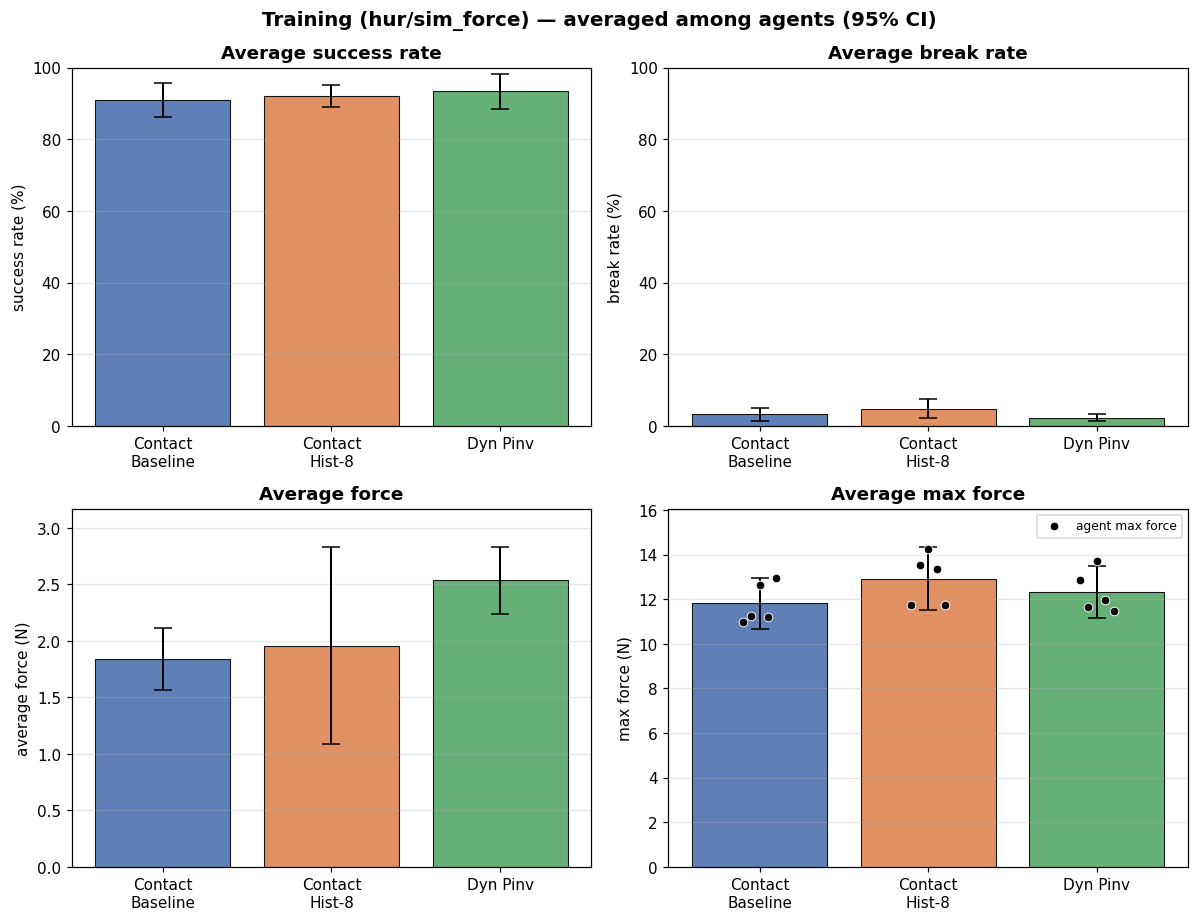

In [4]:
import os
os.makedirs(FIG_DIR, exist_ok=True)


def ci95_halfwidth(vals):
    "Half-width of the CI% confidence interval (t-based); 0 for n<2."
    v = np.asarray(vals, float)
    v = v[np.isfinite(v)]
    n = len(v)
    if n < 2:
        return 0.0
    sem = v.std(ddof=1) / np.sqrt(n)
    return float(stats.t.ppf(0.5 + CI / 2, n - 1) * sem)


def method_samples(col):
    "Dict {method: array of per-agent values} for a per_agent column."
    return {m: per_agent.loc[per_agent["method"] == m, col].to_numpy() for m in METHODS}


def bar_ci(ax, samples_by_method, ylabel, title, dots_by_method=None, dots_label=None):
    xs = np.arange(len(METHODS))
    means = [np.nanmean(samples_by_method[m]) for m in METHODS]
    errs  = [ci95_halfwidth(samples_by_method[m]) for m in METHODS]
    ax.bar(xs, means, yerr=errs, capsize=6,
           color=[METHOD_COLORS[m] for m in METHODS],
           edgecolor="black", linewidth=0.7, alpha=0.9,
           error_kw=dict(ecolor="black", lw=1.3))
    if dots_by_method is not None:
        for i, m in enumerate(METHODS):
            d = np.asarray(dots_by_method[m], float)
            d = d[np.isfinite(d)]
            jit = (np.arange(len(d)) - (len(d) - 1) / 2) * 0.05
            ax.scatter(np.full(len(d), xs[i]) + jit, d, s=32, color="black",
                       edgecolor="white", linewidth=0.6, zorder=5,
                       label=dots_label if i == 0 else None)
        if dots_label:
            ax.legend(fontsize=8, loc="upper right")
    ax.set_xticks(xs)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.margins(y=0.12)
    ax.grid(axis="y", alpha=0.3)


maxf = method_samples("max_force")     # each agent's max force (dots)

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
bar_ci(axes[0, 0], method_samples("success_rate"),
       "success rate (%)", "Average success rate")
bar_ci(axes[0, 1], method_samples("break_rate"),
       "break rate (%)", "Average break rate")
bar_ci(axes[1, 0], method_samples("avg_force"),
       "average force (N)", "Average force")
bar_ci(axes[1, 1], maxf,
       "max force (N)", "Average max force",
       dots_by_method=maxf, dots_label="agent max force")
axes[0, 0].set_ylim(0, 100)
axes[0, 1].set_ylim(0, 100)
fig.suptitle(f"Training ({ENTITY}/{PROJECT}) — averaged among agents (95% CI)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "among_agents.svg"), bbox_inches="tight")
plt.show()

## Plot 2 — stacked per-agent **rates**

One bar per method, stacked into per-agent segments: final **success rate** (left) and
**break rate** (right). Each segment is labeled with that agent's value. (Stacked rates are
a per-agent breakdown, not a count — the stack height is the sum of the agents' rates.)

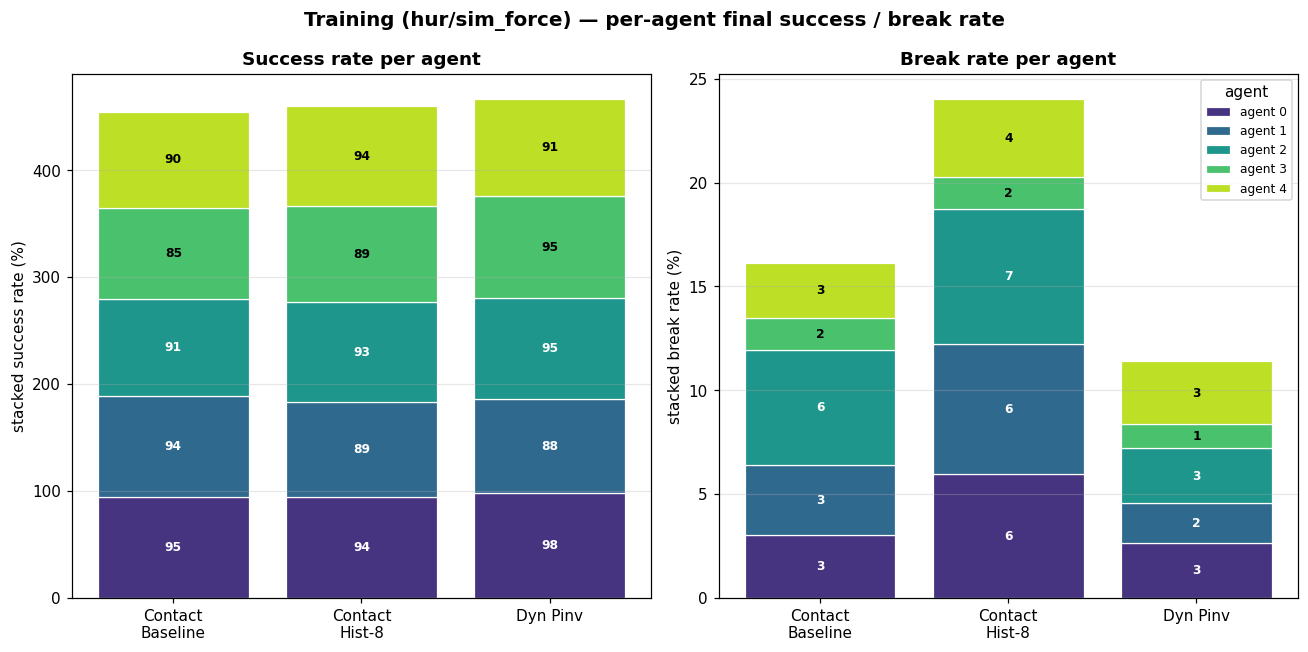

In [5]:
def stacked_rates(ax, col, title, ylabel):
    xs = np.arange(len(METHODS))
    agents = sorted(per_agent["agent"].unique())
    colors = AGENT_CMAP(np.linspace(0.15, 0.9, len(agents)))
    bottoms = np.zeros(len(METHODS))
    for j, agent in enumerate(agents):
        vals = []
        for m in METHODS:
            sub = per_agent[(per_agent["method"] == m) & (per_agent["agent"] == agent)]
            vals.append(float(sub[col].iloc[0]) if len(sub) else 0.0)
        vals = np.array(vals)
        ax.bar(xs, vals, bottom=bottoms, color=colors[j],
               edgecolor="white", linewidth=0.8, label=f"agent {agent}")
        for x, v, b in zip(xs, vals, bottoms):
            if v > 0:
                ax.text(x, b + v / 2, f"{v:.0f}", ha="center", va="center",
                        fontsize=8, fontweight="bold",
                        color="white" if j < len(agents) - 2 else "black")
        bottoms += vals
    ax.set_xticks(xs)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
stacked_rates(axes[0], "success_rate", "Success rate per agent", "stacked success rate (%)")
stacked_rates(axes[1], "break_rate", "Break rate per agent", "stacked break rate (%)")
axes[1].legend(fontsize=8, loc="upper right", title="agent")
fig.suptitle(f"Training ({ENTITY}/{PROJECT}) — per-agent final success / break rate",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "stacked_rates.svg"), bbox_inches="tight")
plt.show()

## Plot 3 — learning curves (success rate & mean reward vs env steps)

Uses each run's logged **history** (not the final summary): `Episode / Success rate` and
`Reward / Total reward (mean)` against env steps (`_step`). Per method, each agent's series is
interpolated onto a shared step grid (their overlapping range) so the line is the across-agent
mean and the band is the 95% CI (t-interval) at each step.

history: 1995 points, 3 methods, step range 150..19950


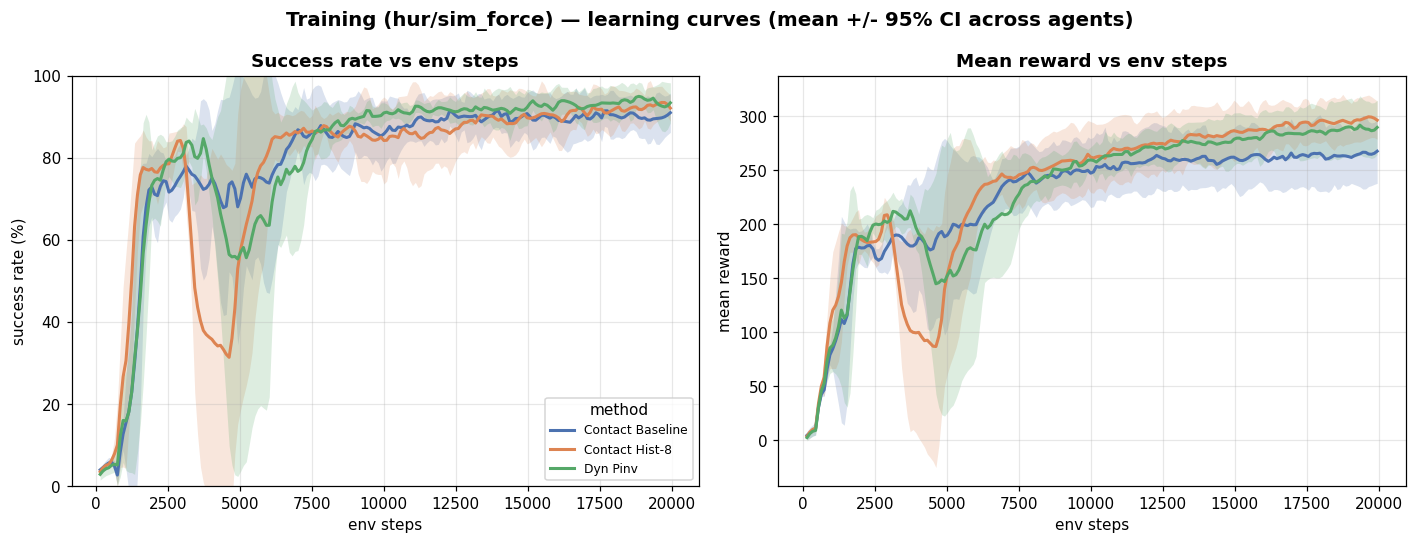

In [6]:
# ---- pull metric history (time series) for the learning curves ----
_runs = api.runs(f"{ENTITY}/{PROJECT}", filters=filters)
hist_rows = []
for r in _runs:
    if TAG and TAG not in (r.tags or []):
        continue
    h = r.history(keys=[KEY_SUCCESS, KEY_REWARD], x_axis="_step", pandas=True)
    if h.empty:
        continue
    h = h.rename(columns={"_step": "step", KEY_SUCCESS: "success_rate", KEY_REWARD: "reward"})
    h["success_rate"] = 100.0 * h["success_rate"]      # fraction -> %
    m = re.search(r"agent[_-]?(\d+)", r.name or "")
    h["method"] = r.group
    h["agent"] = int(m.group(1)) if m else -1
    hist_rows.append(h[["method", "agent", "step", "success_rate", "reward"]])

hist = pd.concat(hist_rows, ignore_index=True)
print(f"history: {len(hist)} points, {hist['method'].nunique()} methods, "
      f"step range {hist['step'].min():.0f}..{hist['step'].max():.0f}")


def method_band(col, method, n=200):
    "Across-agent mean + 95% CI band for `col` vs step, on a shared overlapping grid."
    series = []
    for a in sorted(hist.loc[hist["method"] == method, "agent"].unique()):
        d = (hist[(hist["method"] == method) & (hist["agent"] == a)]
             .dropna(subset=[col]).sort_values("step"))
        if len(d) >= 2:
            series.append((d["step"].to_numpy(float), d[col].to_numpy(float)))
    if not series:
        return None
    lo = max(sx.min() for sx, _ in series)     # overlapping range across agents
    hi = min(sx.max() for sx, _ in series)
    grid = np.linspace(lo, hi, n)
    M = np.vstack([np.interp(grid, sx, sy) for sx, sy in series])   # (n_agents, n)
    mean = M.mean(axis=0)
    k = M.shape[0]
    if k >= 2:
        half = stats.t.ppf(0.5 + CI / 2, k - 1) * M.std(axis=0, ddof=1) / np.sqrt(k)
    else:
        half = np.zeros_like(mean)
    return grid, mean, mean - half, mean + half


def curve_panel(ax, col, ylabel, title):
    for m in METHODS:
        band = method_band(col, m)
        if band is None:
            continue
        grid, mean, lo, hi = band
        ax.plot(grid, mean, color=METHOD_COLORS[m], lw=2,
                label=METHOD_LABELS[m].replace("\n", " "))
        ax.fill_between(grid, lo, hi, color=METHOD_COLORS[m], alpha=0.2, linewidth=0)
    ax.set_xlabel("env steps")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(alpha=0.3)


os.makedirs(FIG_DIR, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
curve_panel(axes[0], "success_rate", "success rate (%)", "Success rate vs env steps")
curve_panel(axes[1], "reward", "mean reward", "Mean reward vs env steps")
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=8, loc="lower right", title="method")
fig.suptitle(f"Training ({ENTITY}/{PROJECT}) — learning curves (mean +/- 95% CI across agents)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "learning_curves.svg"), bbox_inches="tight")
plt.show()